In [1]:
# Core imports – use TensorFlow Keras (compatible with Keras 3)
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Flatten,
    Dropout,
    BatchNormalization,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    TensorBoard,
)

print("TensorFlow version:", __import__("tensorflow").__version__)



2026-05-04 13:12:04.985652: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777900324.999028      55 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777900325.003152      55 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-04 13:12:05.020423: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

TensorFlow version: 2.18.0


In [2]:
# Resolve the base directory – try the Kaggle standard path first,
# fall back to a relative 'input' folder if it exists.
possible_paths = [
    "/kaggle/input/aerial-cactus-identification",
    os.path.join("input", "aerial-cactus-identification"),
]
base_dir = next((p for p in possible_paths if os.path.isdir(p)), None)
if base_dir is None:
    raise FileNotFoundError("Could not locate the dataset directory.")

# CSV paths
train_csv_path = os.path.join(base_dir, "train.csv")
sample_sub_path = os.path.join(base_dir, "sample_submission.csv")
train_df = pd.read_csv(train_csv_path)

# Image folders
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

print("Training data head:")
print(train_df.head())



Training data head:
                                     id  has_cactus
0  2de8f189f1dce439766637e75df0ee27.jpg           1
1  36704d250f236238e7f996812c48235d.jpg           1
2  eacde22fdc8c175972a5768e3daa8bc9.jpg           1
3  5d442f834da5e57d22b24802c32a8ca8.jpg           1
4  152491e0daf75c0e669400300ff7e645.jpg           1


In [3]:
# ImageDataGenerator – keep validation split for quick hold‑out
batch_size = 64

datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    horizontal_flip=True,
    vertical_flip=False,
    validation_split=0.1,
)

# flow_from_dataframe expects string labels for class_mode='binary'
train_df["has_cactus"] = train_df["has_cactus"].astype(str)

data_args = {
    "dataframe": train_df,
    "directory": train_dir,
    "x_col": "id",
    "y_col": "has_cactus",
    "shuffle": True,
    "target_size": (32, 32),
    "batch_size": batch_size,
    "class_mode": "binary",
}

train_generator = datagen.flow_from_dataframe(subset="training", **data_args)
validation_generator = datagen.flow_from_dataframe(subset="validation", **data_args)



Found 12758 validated image filenames belonging to 2 classes.
Found 1417 validated image filenames belonging to 2 classes.


In [4]:
# Build the CNN model (unchanged architecture)
model = Sequential(
    [
        Conv2D(128, (3, 3), activation="relu", input_shape=(32, 32, 3)),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation="relu"),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.2),
        Conv2D(64, (3, 3), activation="relu"),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation="relu"),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.2),
        Flatten(),
        Dense(256, activation="relu"),
        Dropout(0.4),
        Dense(256, activation="relu"),
        Dropout(0.4),
        Dense(1, activation="sigmoid"),
    ]
)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
model.summary()



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-04 13:12:13.326040: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1777900333.326487      55 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:c5:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 10, 10, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       409,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 739,329 (2.82 MB)

 Trainable params: 738,561 (2.82 MB)

 Non-trainable params: 768 (3.00 KB)

In [5]:
# Callbacks – use TensorFlow Keras versions
ckpt_path = "aerial_cactus_detection.keras"

earlystop = EarlyStopping(
    monitor="val_accuracy", patience=10, verbose=1, restore_best_weights=False
)
reducelr = ReduceLROnPlateau(
    monitor="val_accuracy", factor=0.5, patience=3, verbose=1, min_lr=1e-6
)
modelckpt_cb = ModelCheckpoint(
    ckpt_path, monitor="val_accuracy", verbose=1, save_best_only=True, mode="max"
)
tb = TensorBoard(log_dir="logs")

callbacks = [earlystop, reducelr, modelckpt_cb, tb]



In [6]:
# Train the model – steps are derived from the generators
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_steps=validation_generator.samples // batch_size,
    epochs=30,
    verbose=1,
    shuffle=True,
    callbacks=callbacks,
)



/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


I0000 00:00:1777900336.296966     108 service.cc:148] XLA service 0x7f6b70005540 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777900336.297004     108 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-05-04 13:12:16.347680: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777900336.621177     108 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1777900339.441619     108 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8972 - loss: 0.2843

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_accuracy improved from -inf to 0.23722, saving model to aerial_cactus_detection.keras
199/199 ━━━━━━━━━━━━━━━━━━━━ 24s 95ms/step - accuracy: 0.8975 - loss: 0.2836 - val_accuracy: 0.2372 - val_loss: 6.0425 - learning_rate: 0.0010
Epoch 2/30
  1/199 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9688 - loss: 0.0850

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.23722
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9688 - loss: 0.0850 - val_accuracy: 0.2372 - val_loss: 6.0844 - learning_rate: 0.0010
Epoch 3/30
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9757 - loss: 0.0704
Epoch 3: val_accuracy improved from 0.23722 to 0.48651, saving model to aerial_cactus_detection.keras
199/199 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.9757 - loss: 0.0704 - val_accuracy: 0.4865 - val_loss: 2.1574 - learning_rate: 0.0010
Epoch 4/30
  1/199 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9531 - loss: 0.1544
Epoch 4: val_accuracy improved from 0.48651 to 0.61790, saving model to aerial_cactus_detection.keras
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9531 - loss: 0.1544 - val_accuracy: 0.6179 - val_loss: 1.2971 - learning_rate: 0.0010
Epoch 5/30
198/199 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9820 - loss: 0.0528
Epoch 5: val_accuracy improved from 0.61790 to 0.94105, savi

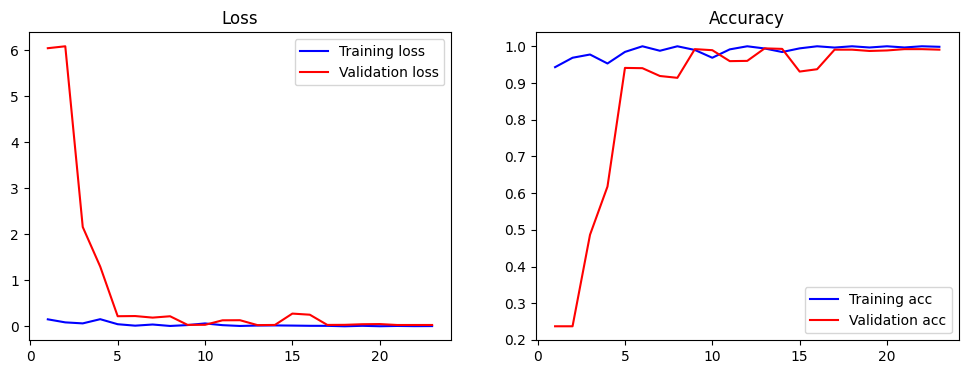

In [7]:
# Plot training history (optional – does not affect submission)
epochs_range = range(1, len(history.history["loss"]) + 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history["loss"], "b", label="Training loss")
plt.plot(epochs_range, history.history["val_loss"], "r", label="Validation loss")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history["accuracy"], "b", label="Training acc")
plt.plot(epochs_range, history.history["val_accuracy"], "r", label="Validation acc")
plt.title("Accuracy")
plt.legend()
plt.show()



In [8]:
# Load test images via the generator to keep preprocessing consistent
test_df = pd.read_csv(sample_sub_path)
print("Sample submission head:")
print(test_df.head())

test_images = []
for image_id in tqdm(test_df["id"].values, desc="Loading test images"):
    img_path = os.path.join(test_dir, image_id)
    img = cv2.imread(img_path)
    if img is not None:
        test_images.append(img)
    else:
        # Fallback to a black image if missing
        test_images.append(np.zeros((32, 32, 3), dtype=np.uint8))

test_images = np.asarray(test_images, dtype=np.float32) / 255.0
print("Number of test images loaded:", len(test_images))



Sample submission head:
                                     id  has_cactus
0  09034a34de0e2015a8a28dfe18f423f6.jpg         0.5
1  134f04305c795d6d202502c2ce3578f3.jpg         0.5
2  41fad8d145e6c41868ce3617e30a2545.jpg         0.5
3  35f8a11352c8d41b6231bb33d8d09f7e.jpg         0.5
4  b77dc902b035887cbbc01920ce0e3151.jpg         0.5


Loading test images: 100%|██████████| 3325/3325 [00:02<00:00, 1316.93it/s]


Number of test images loaded: 3325


In [9]:
# Predict and create the submission file
pred = model.predict(test_images, verbose=0).reshape(-1)
test_df["has_cactus"] = pred
submission_path = "submission.csv"
test_df.to_csv(submission_path, index=False)
print(f"Submission saved to {submission_path}")

Submission saved to submission.csv
